In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# =========================================
# 1. Base path
# =========================================
BASE_PATH = "/kaggle/input/datasets/ameersifat53/ppg-dalia-dataset/PPG_FieldStudy"

In [3]:
# =========================================
# 2. Find all subject folders
# =========================================
subjects = sorted([
    folder for folder in os.listdir(BASE_PATH)
    if folder.startswith("S") and os.path.isdir(os.path.join(BASE_PATH, folder))
])

print("Subjects found:")
print(subjects)
print("Total subjects:", len(subjects))

Subjects found:
['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Total subjects: 15


In [4]:
# =========================================
# 3. Load all subjects
# =========================================
all_data = {}

for subject in subjects:
    subject_path = os.path.join(BASE_PATH, subject)
    pkl_path = os.path.join(subject_path, f"{subject}.pkl")

    if not os.path.exists(pkl_path):
        print(f"Skipping {subject} - .pkl file not found")
        continue

    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    subject_dict = {}

    # Extract wrist signals
    if "signal" in data and "wrist" in data["signal"]:
        wrist = data["signal"]["wrist"]
        subject_dict["bvp"] = np.array(wrist["BVP"]) if "BVP" in wrist else None
        subject_dict["acc_wrist"] = np.array(wrist["ACC"]) if "ACC" in wrist else None
        subject_dict["eda_wrist"] = np.array(wrist["EDA"]) if "EDA" in wrist else None
        subject_dict["temp_wrist"] = np.array(wrist["TEMP"]) if "TEMP" in wrist else None
    else:
        subject_dict["bvp"] = None
        subject_dict["acc_wrist"] = None
        subject_dict["eda_wrist"] = None
        subject_dict["temp_wrist"] = None

    # Extract chest signals
    if "signal" in data and "chest" in data["signal"]:
        chest = data["signal"]["chest"]
        subject_dict["ecg"] = np.array(chest["ECG"]) if "ECG" in chest else None
        subject_dict["acc_chest"] = np.array(chest["ACC"]) if "ACC" in chest else None
        subject_dict["resp"] = np.array(chest["Resp"]) if "Resp" in chest else None
        subject_dict["eda_chest"] = np.array(chest["EDA"]) if "EDA" in chest else None
        subject_dict["temp_chest"] = np.array(chest["Temp"]) if "Temp" in chest else None
        subject_dict["emg"] = np.array(chest["EMG"]) if "EMG" in chest else None
    else:
        subject_dict["ecg"] = None
        subject_dict["acc_chest"] = None
        subject_dict["resp"] = None
        subject_dict["eda_chest"] = None
        subject_dict["temp_chest"] = None
        subject_dict["emg"] = None

    # Labels / activity
    subject_dict["label"] = np.array(data["label"]) if "label" in data else None
    subject_dict["activity"] = np.array(data["activity"]) if "activity" in data else None

    all_data[subject] = subject_dict

print("\nFinished loading all subjects.")
print("Loaded subjects:", list(all_data.keys()))



Finished loading all subjects.
Loaded subjects: ['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [5]:
print("\n========== DATA SUMMARY ==========\n")

for subject, subject_data in all_data.items():
    print(f"{subject}:")
    
    for key, value in subject_data.items():
        if value is None:
            print(f"  {key}: None")
        else:
            print(f"  {key}: shape = {value.shape}, dtype = {value.dtype}")
    
    print("-" * 50)





========== DATA SUMMARY ==========

S1:
  bvp: shape = (589568, 1), dtype = float64
  acc_wrist: shape = (294784, 3), dtype = float64
  eda_wrist: shape = (36848, 1), dtype = float64
  temp_wrist: shape = (36848, 1), dtype = float64
  ecg: shape = (6448400, 1), dtype = float64
  acc_chest: shape = (6448400, 3), dtype = float64
  resp: shape = (6448400, 1), dtype = float64
  eda_chest: shape = (6448400, 1), dtype = float64
  temp_chest: shape = (6448400, 1), dtype = float32
  emg: shape = (6448400, 1), dtype = float64
  label: shape = (4603,), dtype = float64
  activity: shape = (36848, 1), dtype = float64
--------------------------------------------------
S10:
  bvp: shape = (681472, 1), dtype = float64
  acc_wrist: shape = (340736, 3), dtype = float64
  eda_wrist: shape = (42592, 1), dtype = float64
  temp_wrist: shape = (42592, 1), dtype = float64
  ecg: shape = (7453600, 1), dtype = float64
  acc_chest: shape = (7453600, 3), dtype = float64
  resp: shape = (7453600, 1), dtype = flo

In [6]:
print("\n========== SAMPLE VALUES ==========\n")

for subject, subject_data in all_data.items():
    print(f"{subject}:")
    
    if subject_data["bvp"] is not None:
        print("  First 5 BVP values:", subject_data["bvp"][:5].flatten())
    
    if subject_data["ecg"] is not None:
        print("  First 5 ECG values:", subject_data["ecg"][:5].flatten())
    
    if subject_data["acc_wrist"] is not None:
        print("  First 3 wrist ACC values:")
        print(subject_data["acc_wrist"][:3])
    
    print("-" * 50)


========== SAMPLE VALUES ==========

S1:
  First 5 BVP values: [7.28 6.33 5.46 4.6  3.74]
  First 5 ECG values: [0.01560974 0.01812744 0.01753235 0.01341248 0.01194763]
  First 3 wrist ACC values:
[[-0.765625 -0.078125  0.671875]
 [-0.765625 -0.078125  0.65625 ]
 [-0.765625 -0.078125  0.671875]]
--------------------------------------------------
S10:
  First 5 BVP values: [7.87 7.03 6.33 5.69 4.94]
  First 5 ECG values: [-0.10047913 -0.09690857 -0.09242249 -0.08802795 -0.08418274]
  First 3 wrist ACC values:
[[-0.765625  0.25      0.59375 ]
 [-0.765625  0.265625  0.578125]
 [-0.765625  0.25      0.578125]]
--------------------------------------------------
S11:
  First 5 BVP values: [  2.11  -2.47  -6.52  -9.85 -12.61]
  First 5 ECG values: [-0.07594299 -0.0770874  -0.08097839 -0.07635498 -0.07191467]
  First 3 wrist ACC values:
[[-0.734375  0.46875   0.484375]
 [-0.734375  0.46875   0.484375]
 [-0.734375  0.46875   0.484375]]
--------------------------------------------------
S12:
  

In [7]:
all_bvp_list = []
all_ecg_list = []

for subject, subject_data in all_data.items():
    if subject_data["bvp"] is not None:
        all_bvp_list.append(subject_data["bvp"].flatten())
    if subject_data["ecg"] is not None:
        all_ecg_list.append(subject_data["ecg"].flatten())

all_bvp = np.concatenate(all_bvp_list, axis=0)
all_ecg = np.concatenate(all_ecg_list, axis=0)

print("Combined BVP shape:", all_bvp.shape)
print("Combined ECG shape:", all_ecg.shape)

print("First 10 combined BVP values:", all_bvp[:10])
print("First 10 combined ECG values:", all_ecg[:10])



Combined BVP shape: (8287296,)
Combined ECG shape: (90642300,)
First 10 combined BVP values: [ 7.28  6.33  5.46  4.6   3.74  2.86  2.03  1.27  0.57 -0.2 ]
First 10 combined ECG values: [0.01560974 0.01812744 0.01753235 0.01341248 0.01194763 0.0133667
 0.01304626 0.01313782 0.02146912 0.03144836]


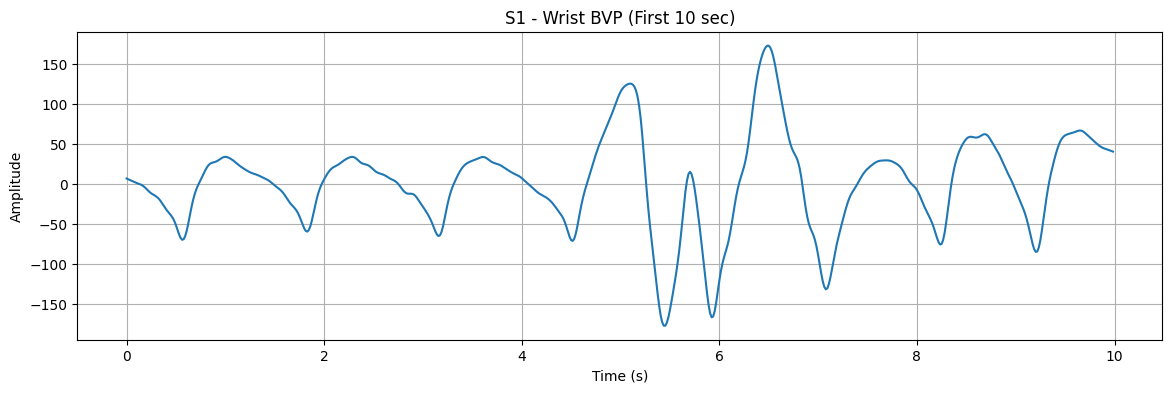

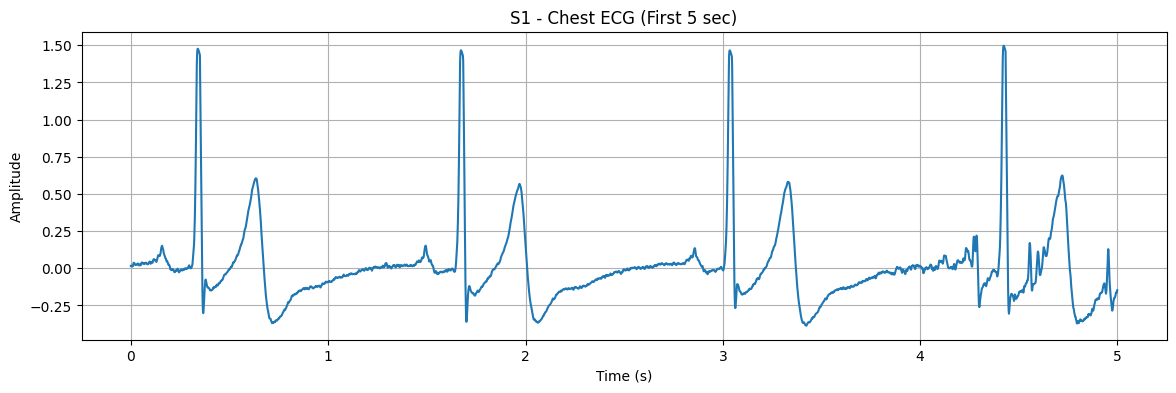

In [8]:
subject_to_plot = "S1"

bvp = all_data[subject_to_plot]["bvp"]
ecg = all_data[subject_to_plot]["ecg"]

FS_BVP = 64
FS_ECG = 700

plot_seconds_bvp = 10
plot_seconds_ecg = 5

n_bvp = FS_BVP * plot_seconds_bvp
n_ecg = FS_ECG * plot_seconds_ecg

bvp_segment = bvp[:n_bvp].flatten()
ecg_segment = ecg[:n_ecg].flatten()

t_bvp = np.arange(len(bvp_segment)) / FS_BVP
t_ecg = np.arange(len(ecg_segment)) / FS_ECG

plt.figure(figsize=(14, 4))
plt.plot(t_bvp, bvp_segment)
plt.title(f"{subject_to_plot} - Wrist BVP (First {plot_seconds_bvp} sec)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(t_ecg, ecg_segment)
plt.title(f"{subject_to_plot} - Chest ECG (First {plot_seconds_ecg} sec)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()



In [9]:

all_data["S1"]["bvp"]
all_data["S1"]["ecg"]
all_data["S8"]["bvp"]
all_data["S15"]["ecg"]


array([[0.46174622],
       [0.43588257],
       [0.40461731],
       ...,
       [0.02256775],
       [0.02549744],
       [0.02366638]])

In [10]:
import math
import random
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.signal import butter, filtfilt, resample_poly, find_peaks
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


2026-03-15 10:22:00.726351: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773570120.747444     540 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773570120.753823     540 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773570120.770541     540 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773570120.770578     540 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773570120.770581     540 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [11]:
# ============================================================
# 1. Assumptions from DALIA
# ============================================================
# Your Code.txt loads:
# all_data[subject]["bvp"]  -> wrist BVP (64 Hz)
# all_data[subject]["ecg"]  -> chest ECG (700 Hz)
#
# If your variable name is different, change here.
# ============================================================

assert "all_data" in globals(), "Please run your DALIA loading code first so that all_data exists."

subjects = sorted(all_data.keys())
print("Subjects:", subjects)
print("Number of subjects:", len(subjects))


Subjects: ['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Number of subjects: 15


In [12]:
# ============================================================
# 2. Paper-faithful preprocessing parameters
# ============================================================
# Paper:
# - resample PPG to 128 Hz
# - Butterworth bandpass 0.5-8 Hz
# - 4 sec windows for training = 512 samples
# - 25% overlap
# - min-max normalize to [-1, 1]
# ============================================================

ORIG_FS_BVP = 64
ORIG_FS_ECG = 700
TARGET_FS = 128

TRAIN_WINDOW_SEC = 4
TRAIN_WINDOW_SAMPLES = TARGET_FS * TRAIN_WINDOW_SEC   # 512

OVERLAP_RATIO = 0.25
STEP_SAMPLES = int(TRAIN_WINDOW_SAMPLES * (1 - OVERLAP_RATIO))  # 384

BANDPASS_LOW = 0.5
BANDPASS_HIGH = 8.0
BUTTER_ORDER = 4 # Butter worth order

BATCH_SIZE = 64 #Batch sizes
EPOCHS = 5

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_GEN_PATH = os.path.join(CHECKPOINT_DIR, "best_generator.weights.h5")
LAST_GEN_PATH = os.path.join(CHECKPOINT_DIR, "last_generator.weights.h5")
BEST_DISC_PATH = os.path.join(CHECKPOINT_DIR, "best_discriminator.weights.h5")
LAST_DISC_PATH = os.path.join(CHECKPOINT_DIR, "last_discriminator.weights.h5")



In [13]:
# ============================================================
# 3. Signal utilities
# ============================================================

#Butterworth filter
def butter_bandpass_filter(signal, fs, lowcut=0.5, highcut=8.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

#Normalization
def minmax_scale_minus1_to_1(x):
    x = np.asarray(x, dtype=np.float32)
    xmin = np.min(x)
    xmax = np.max(x)
    if np.isclose(xmax, xmin):
        return np.zeros_like(x, dtype=np.float32)
    return 2.0 * (x - xmin) / (xmax - xmin) - 1.0

#Signal segmentation
def segment_signal(signal, window_size, step_size):
    segments = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        segments.append(signal[start:end])
    return np.array(segments)


def safe_flatten(x):
    return np.asarray(x).astype(np.float32).reshape(-1)


# ============================================================
# 4. ECG-based HR estimation
# ============================================================


In [14]:
#Estimate the heart rate from ECG
def estimate_hr_from_ecg_window(ecg_window, fs=ORIG_FS_ECG):
    x = np.asarray(ecg_window).astype(np.float32)
    x = x - np.mean(x)
    std = np.std(x) + 1e-8
    x = x / std

    min_distance = int(fs * (60.0 / 220.0))
    min_distance = max(min_distance, 1)

    peaks, _ = find_peaks(x, distance=min_distance, prominence=0.5)

    if len(peaks) < 2:
        return np.nan

    rr_intervals = np.diff(peaks) / fs
    rr_intervals = rr_intervals[(rr_intervals > 0.27) & (rr_intervals < 2.0)]

    if len(rr_intervals) == 0:
        return np.nan

    return 60.0 / np.mean(rr_intervals)

#Estimate heart rate from PPG generated from generator
from scipy.signal import savgol_filter

def estimate_hr_from_generated_ppg(ppg_window, fs=TARGET_FS):
    x = np.asarray(ppg_window).astype(np.float32)
    x = x - np.mean(x)

    # smooth before peak detection
    if len(x) >= 11:
        x = savgol_filter(x, 11, 2)

    min_distance = int(fs * (60.0 / 220.0))
    min_distance = max(min_distance, 1)

    prominence = max(0.03, 0.20 * np.std(x))
    peaks, _ = find_peaks(x, distance=min_distance, prominence=prominence)

    if len(peaks) < 2:
        return np.nan

    pp_intervals = np.diff(peaks) / fs
    pp_intervals = pp_intervals[(pp_intervals > 0.27) & (pp_intervals < 2.0)]

    if len(pp_intervals) == 0:
        return np.nan

    return 60.0 / np.mean(pp_intervals)


# ============================================================
# 5. Ideal PPG synthesis from the paper
# ============================================================
# Paper formula:
# PPG_i(t) = 0.8 cos(2π f_HR t + θ) - 0.35 sin(2(2π f_HR t + θ))
# ============================================================


In [15]:
#Synthesize of Mathematical PPG
def synthesize_ideal_ppg(hr_bpm, length=TRAIN_WINDOW_SAMPLES, fs=TARGET_FS, theta=0.0):
    f_hr = hr_bpm / 60.0
    t = np.arange(length) / fs

    ideal = 0.8 * np.cos(2 * np.pi * f_hr * t + theta) \
            - 0.35 * np.sin(2 * (2 * np.pi * f_hr * t + theta))

    ideal = minmax_scale_minus1_to_1(ideal)
    return ideal.astype(np.float32)


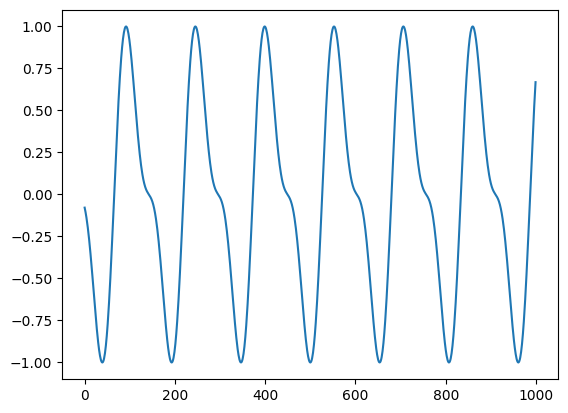

In [16]:
x=synthesize_ideal_ppg(50, 1000, 128, 90)
plt.plot(x)

# ============================================================
# 6. Subject-wise preprocessing
# ============================================================


In [17]:
def preprocess_subject(subject_name, subject_dict):
    bvp = safe_flatten(subject_dict["bvp"])
    ecg = safe_flatten(subject_dict["ecg"])

    # Resample BVP only: 64 -> 128
    bvp_rs = resample_poly(bvp, up=2, down=1)

    # Filter BVP
    bvp_filt = butter_bandpass_filter(
        bvp_rs,
        fs=TARGET_FS,
        lowcut=BANDPASS_LOW,
        highcut=BANDPASS_HIGH,
        order=BUTTER_ORDER
    )

    # Segment BVP at 128 Hz
    bvp_windows = segment_signal(bvp_filt, TRAIN_WINDOW_SAMPLES, STEP_SAMPLES)

    X_noisy = []
    X_ideal = []
    y_hr = []
    meta = []

    for i in range(len(bvp_windows)):
        ppg_w = bvp_windows[i]

        # Convert this 128 Hz BVP window position back to time
        start_bvp_128 = i * STEP_SAMPLES
        end_bvp_128 = start_bvp_128 + TRAIN_WINDOW_SAMPLES

        start_time_sec = start_bvp_128 / TARGET_FS
        end_time_sec = end_bvp_128 / TARGET_FS

        # Extract matching raw ECG window at 700 Hz
        ecg_start = int(start_time_sec * ORIG_FS_ECG)
        ecg_end = int(end_time_sec * ORIG_FS_ECG)

        if ecg_end > len(ecg):
            continue

        ecg_w_raw = ecg[ecg_start:ecg_end]

        hr = estimate_hr_from_ecg_window(ecg_w_raw, fs=ORIG_FS_ECG)
        if np.isnan(hr):
            continue

        if hr < 40 or hr > 200:
            continue

        ppg_w = minmax_scale_minus1_to_1(ppg_w)
        ideal_w = synthesize_ideal_ppg(hr_bpm=hr, length=TRAIN_WINDOW_SAMPLES, fs=TARGET_FS)

        X_noisy.append(ppg_w.astype(np.float32))
        X_ideal.append(ideal_w.astype(np.float32))
        y_hr.append(np.float32(hr))
        meta.append((subject_name, i))

    if len(X_noisy) == 0:
        return None

    X_noisy = np.array(X_noisy, dtype=np.float32)[..., np.newaxis]
    X_ideal = np.array(X_ideal, dtype=np.float32)[..., np.newaxis]
    y_hr = np.array(y_hr, dtype=np.float32)

    return {
        "X_noisy": X_noisy,
        "X_ideal": X_ideal,
        "y_hr": y_hr,
        "meta": meta
    }

# ============================================================
# 7. Build full dataset subject-wise
# ============================================================


In [18]:
subject_processed = {}

for s in tqdm(subjects, desc="Preprocessing subjects"):
    out = preprocess_subject(s, all_data[s])
    if out is not None:
        subject_processed[s] = out

valid_subjects = sorted(subject_processed.keys())
print("Usable subjects:", valid_subjects)
print("Usable subject count:", len(valid_subjects))



Preprocessing subjects:   0%|          | 0/15 [00:00<?, ?it/s]

Usable subjects: ['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Usable subject count: 15


# ============================================================
# 8. Subject-wise split
# ============================================================
# Paper uses participant-separated splits.
# Since you also want a best validation model, we do:
# - 80% train_val subjects
# - 20% test subjects
# - from train_val, carve out validation subjects
#
# This avoids leakage across windows of the same subject.
# ============================================================



In [19]:
trainval_subjects, test_subjects = train_test_split(
    valid_subjects, test_size=0.20, random_state=SEED
)

train_subjects, val_subjects = train_test_split(
    trainval_subjects, test_size=0.20, random_state=SEED
)

print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Test subjects:", test_subjects)

def gather_subjects(subject_list):
    Xn, Xi, y, meta = [], [], [], []
    for s in subject_list:
        Xn.append(subject_processed[s]["X_noisy"])
        Xi.append(subject_processed[s]["X_ideal"])
        y.append(subject_processed[s]["y_hr"])
        meta.extend(subject_processed[s]["meta"])
    return (
        np.concatenate(Xn, axis=0),
        np.concatenate(Xi, axis=0),
        np.concatenate(y, axis=0),
        meta
    )

X_train_noisy, X_train_ideal, y_train_hr, meta_train = gather_subjects(train_subjects)
X_val_noisy, X_val_ideal, y_val_hr, meta_val = gather_subjects(val_subjects)
X_test_noisy, X_test_ideal, y_test_hr, meta_test = gather_subjects(test_subjects)

print("\nDataset shapes")
print("Train noisy:", X_train_noisy.shape)
print("Train ideal:", X_train_ideal.shape)
print("Val noisy:", X_val_noisy.shape)
print("Val ideal:", X_val_ideal.shape)
print("Test noisy:", X_test_noisy.shape)
print("Test ideal:", X_test_ideal.shape)


Train subjects: ['S5', 'S9', 'S3', 'S14', 'S15', 'S10', 'S2', 'S11', 'S13']
Val subjects: ['S12', 'S7', 'S8']
Test subjects: ['S4', 'S6', 'S1']

Dataset shapes
Train noisy: (26840, 512, 1)
Train ideal: (26840, 512, 1)
Val noisy: (8439, 512, 1)
Val ideal: (8439, 512, 1)
Test noisy: (7867, 512, 1)
Test ideal: (7867, 512, 1)


# ============================================================
# 9. tf.data pipelines
# ============================================================


In [20]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X_noisy, X_ideal, y_hr, batch_size=128, training=True):
    ds = tf.data.Dataset.from_tensor_slices((X_noisy, X_ideal, y_hr))
    if training:
        ds = ds.shuffle(min(len(X_noisy), 10000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train_noisy, X_train_ideal, y_train_hr, batch_size=BATCH_SIZE, training=True)
val_ds = make_dataset(X_val_noisy, X_val_ideal, y_val_hr, batch_size=BATCH_SIZE, training=False)
test_ds = make_dataset(X_test_noisy, X_test_ideal, y_test_hr, batch_size=BATCH_SIZE, training=False)


I0000 00:00:1773570146.444108     540 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# ============================================================
# 10. Generator and Discriminator
# ============================================================
# Paper:
# Generator:
# - encoder-decoder
# - conv filters 64,128,256
# - kernel 16, stride 2
# - layer norm + leaky ReLU in encoder
# - decoder deconv filters 256,128,64
# - layer norm + ReLU in decoder
# - final tanh
#
# Discriminator:
# - conv filters 512,256,128,64
# - kernel 16, stride 2
# - leaky ReLU + batch norm
# - flatten + dense(1)
# ============================================================


In [21]:
def build_generator(input_shape=(TRAIN_WINDOW_SAMPLES, 1)):
    inp = layers.Input(shape=input_shape)

    # Encoder
    x = layers.Conv1D(64, kernel_size=16, strides=2, padding="same")(inp)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    skip1 = x

    x = layers.Conv1D(128, kernel_size=16, strides=2, padding="same")(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    skip2 = x

    x = layers.Conv1D(256, kernel_size=16, strides=2, padding="same")(x)
    x = layers.LayerNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # Decoder
    x = layers.Conv1DTranspose(256, kernel_size=16, strides=2, padding="same")(x)
    x = layers.LayerNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Concatenate()([x, skip2])

    x = layers.Conv1DTranspose(128, kernel_size=16, strides=2, padding="same")(x)
    x = layers.LayerNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Concatenate()([x, skip1])

    x = layers.Conv1DTranspose(64, kernel_size=16, strides=2, padding="same")(x)
    x = layers.LayerNormalization()(x)
    x = layers.ReLU()(x)

    out = layers.Conv1D(1, kernel_size=15, padding="same", activation="tanh")(x)

    model = models.Model(inp, out, name="Generator")
    return model

def build_discriminator(input_shape=(TRAIN_WINDOW_SAMPLES, 1)):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv1D(256, kernel_size=16, strides=2, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv1D(128, kernel_size=16, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv1D(64, kernel_size=16, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Conv1D(32, kernel_size=16, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1)(x)

    model = models.Model(inp, out, name="Discriminator")
    return model

generator = build_generator()
discriminator = build_discriminator()

print("\nGenerator summary")
generator.summary()

print("\nDiscriminator summary")
discriminator.summary()



Generator summary


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 64)   │      1,088 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 256, 64)   │        128 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256, 64)   │          0 │ layer_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │    131,200 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 128, 128)  │          0 │ layer_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 64, 256)   │    524,544 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ conv1d_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 64, 256)   │          0 │ layer_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose    │ (None, 128, 256)  │  1,048,832 │ leaky_re_lu_2[0]… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 256)  │        512 │ conv1d_transpose… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 256)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 384)  │          0 │ re_lu[0][0],      │
│ (Concatenate)       │                   │            │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose_1  │ (None, 256, 128)  │    786,560 │ concatenate[0][0] │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256, 128)  │        256 │ conv1d_transpose… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 128)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 192)  │          0 │ re_lu_1[0][0],    │
│ (Concatenate)       │                   │            │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,691,649 (10.27 MB)

 Trainable params: 2,691,649 (10.27 MB)

...

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 256, 256)       │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 128, 128)       │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 64, 64)         │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 32, 32)         │        32,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 695,649 (2.65 MB)

 Trainable params: 694,689 (2.65 MB)

 Non-trainable params: 960 (3.75 KB)

# ============================================================
# 11. Losses and optimizers
# ============================================================
# Adversarial loss from GAN idea in paper.
# We also add L1 reconstruction loss to stabilize training.
# The paper emphasizes adversarial mapping to ideal representation.
# In practice, L1 helps much more on DALIA-only training.
# ============================================================


In [22]:
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

lr_schedule_g = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True
)

lr_schedule_d = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True
)

gen_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5)

LAMBDA_L1 = 0.0

def discriminator_loss(real_logits, fake_logits):
    real_loss = bce(0.9 * tf.ones_like(real_logits), real_logits)
    fake_loss = bce(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

def generator_loss(fake_logits, fake_signal, target_signal):
    adv_loss = bce(tf.ones_like(fake_logits), fake_logits)
    l1_loss = tf.reduce_mean(tf.abs(fake_signal - target_signal))
    total = adv_loss + LAMBDA_L1 * l1_loss
    return total, adv_loss, l1_loss

# ============================================================
# 12. Training / validation steps
# ============================================================


In [23]:
@tf.function
def train_step(noisy_ppg, ideal_ppg):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_ppg = generator(noisy_ppg, training=True)

        real_logits = discriminator(ideal_ppg, training=True)
        fake_logits = discriminator(fake_ppg, training=True)

        d_loss = discriminator_loss(real_logits, fake_logits)
        g_total, g_adv, g_l1 = generator_loss(fake_logits, fake_ppg, ideal_ppg)

    gen_grads = gen_tape.gradient(g_total, generator.trainable_variables)
    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return d_loss, g_total, g_adv, g_l1

@tf.function
def val_step(noisy_ppg, ideal_ppg):
    fake_ppg = generator(noisy_ppg, training=False)
    real_logits = discriminator(ideal_ppg, training=False)
    fake_logits = discriminator(fake_ppg, training=False)

    d_loss = discriminator_loss(real_logits, fake_logits)
    g_total, g_adv, g_l1 = generator_loss(fake_logits, fake_ppg, ideal_ppg)
    return d_loss, g_total, g_adv, g_l1, fake_ppg


# ============================================================
# 13. Helper: HR evaluation from generator outputs
# ============================================================



In [24]:
def predict_hr_batch(ppg_batch):
    hrs = []
    for i in range(len(ppg_batch)):
        hrs.append(estimate_hr_from_generated_ppg(ppg_batch[i, :, 0], fs=TARGET_FS))
    return np.array(hrs, dtype=np.float32)

def regression_metrics(y_true, y_pred):
    mask = ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return {
            "mae": np.nan,
            "rmse": np.nan,
            "corr": np.nan,
            "acc_pm3": np.nan,
            "n_valid": 0
        }

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    corr = pearsonr(y_true, y_pred)[0] if len(y_true) > 1 else np.nan
    acc_pm3 = np.mean(np.abs(y_true - y_pred) <= 3.0)

    return {
        "mae": mae,
        "rmse": rmse,
        "corr": corr,
        "acc_pm3": acc_pm3,
        "n_valid": len(y_true)
    }



# ============================================================
# 14. Full training loop with tqdm progress bar
# ============================================================


In [25]:
history = {
    "train_g_total": [],
    "train_g_adv": [],
    "train_g_l1": [],
    "train_d": [],
    "val_g_total": [],
    "val_g_adv": [],
    "val_g_l1": [],
    "val_d": [],
    "val_mae": [],
    "val_rmse": [],
    "val_corr": [],
    "val_acc_pm3": []
}

best_val_mae = np.inf
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    # ---------- TRAIN ----------
    train_d_losses = []
    train_g_losses = []
    train_g_adv_losses = []
    train_g_l1_losses = []

    pbar = tqdm(train_ds, total=len(list(train_ds)), desc=f"Train Epoch {epoch}", leave=False)

    for noisy_batch, ideal_batch, hr_batch in pbar:
        d_loss, g_total, g_adv, g_l1 = train_step(noisy_batch, ideal_batch)

        d_loss_v = float(d_loss.numpy())
        g_total_v = float(g_total.numpy())
        g_adv_v = float(g_adv.numpy())
        g_l1_v = float(g_l1.numpy())

        train_d_losses.append(d_loss_v)
        train_g_losses.append(g_total_v)
        train_g_adv_losses.append(g_adv_v)
        train_g_l1_losses.append(g_l1_v)

        pbar.set_postfix({
            "g_total": f"{np.mean(train_g_losses):.4f}",
            "g_adv": f"{np.mean(train_g_adv_losses):.4f}",
            "g_l1": f"{np.mean(train_g_l1_losses):.4f}",
            "d_loss": f"{np.mean(train_d_losses):.4f}"
        })

    # ---------- VALIDATION ----------
    val_d_losses = []
    val_g_losses = []
    val_g_adv_losses = []
    val_g_l1_losses = []

    all_val_preds = []

    for noisy_batch, ideal_batch, hr_batch in val_ds:
        d_loss, g_total, g_adv, g_l1, fake_ppg = val_step(noisy_batch, ideal_batch)

        val_d_losses.append(float(d_loss.numpy()))
        val_g_losses.append(float(g_total.numpy()))
        val_g_adv_losses.append(float(g_adv.numpy()))
        val_g_l1_losses.append(float(g_l1.numpy()))

        preds_hr = predict_hr_batch(fake_ppg.numpy())
        all_val_preds.append(preds_hr)

    all_val_preds = np.concatenate(all_val_preds, axis=0)
    val_metrics = regression_metrics(y_val_hr, all_val_preds)

    train_g_mean = np.mean(train_g_losses)
    train_g_adv_mean = np.mean(train_g_adv_losses)
    train_g_l1_mean = np.mean(train_g_l1_losses)
    train_d_mean = np.mean(train_d_losses)

    val_g_mean = np.mean(val_g_losses)
    val_g_adv_mean = np.mean(val_g_adv_losses)
    val_g_l1_mean = np.mean(val_g_l1_losses)
    val_d_mean = np.mean(val_d_losses)

    history["train_g_total"].append(train_g_mean)
    history["train_g_adv"].append(train_g_adv_mean)
    history["train_g_l1"].append(train_g_l1_mean)
    history["train_d"].append(train_d_mean)
    history["val_g_total"].append(val_g_mean)
    history["val_g_adv"].append(val_g_adv_mean)
    history["val_g_l1"].append(val_g_l1_mean)
    history["val_d"].append(val_d_mean)

    history["val_mae"].append(val_metrics["mae"])
    history["val_rmse"].append(val_metrics["rmse"])
    history["val_corr"].append(val_metrics["corr"])
    history["val_acc_pm3"].append(val_metrics["acc_pm3"])

    print(
        f"train_g={train_g_mean:.4f} | train_d={train_d_mean:.4f} | "
        f"val_g={val_g_mean:.4f} | val_d={val_d_mean:.4f} | "
        f"val_MAE={val_metrics['mae']:.4f} | val_RMSE={val_metrics['rmse']:.4f} | "
        f"val_corr={val_metrics['corr']:.4f} | val_acc(±3bpm)={val_metrics['acc_pm3']:.4f}"
    )

    # Save overall best only
    if val_metrics["mae"] < best_val_mae:
        best_val_mae = val_metrics["mae"]
        best_epoch = epoch

        generator.save_weights(BEST_GEN_PATH)
        discriminator.save_weights(BEST_DISC_PATH)

        print(f"Best model updated at epoch {epoch} | best val MAE = {best_val_mae:.4f}")

# Save last model after all epochs
generator.save_weights(LAST_GEN_PATH)
discriminator.save_weights(LAST_DISC_PATH)

print("\nTraining finished.")
print("Best epoch:", best_epoch)
print("Best generator saved to:", BEST_GEN_PATH)
print("Last generator saved to:", LAST_GEN_PATH)




Epoch 1/5


Train Epoch 1:   0%|          | 0/420 [00:00<?, ?it/s]

I0000 00:00:1773570155.563282     600 cuda_dnn.cc:529] Loaded cuDNN version 91002


train_g=1.9803 | train_d=0.6687 | val_g=2.3060 | val_d=1.1613 | val_MAE=26.1454 | val_RMSE=33.1177 | val_corr=-0.0901 | val_acc(±3bpm)=0.1046
Best model updated at epoch 1 | best val MAE = 26.1454

Epoch 2/5


Train Epoch 2:   0%|          | 0/420 [00:00<?, ?it/s]

...

train_g=3.4096 | train_d=0.4462 | val_g=3.9969 | val_d=1.2424 | val_MAE=27.0683 | val_RMSE=34.1523 | val_corr=-0.1078 | val_acc(±3bpm)=0.1023

Epoch 4/5


Train Epoch 4:   0%|          | 0/420 [00:00<?, ?it/s]

train_g=3.8499 | train_d=0.4216 | val_g=3.1275 | val_d=1.1827 | val_MAE=22.6130 | val_RMSE=29.7363 | val_corr=0.1334 | val_acc(±3bpm)=0.1298
Best model updated at epoch 4 | best val MAE = 22.6130

Epoch 5/5


Train Epoch 5:   0%|          | 0/420 [00:00<?, ?it/s]

train_g=4.2707 | train_d=0.3922 | val_g=3.5648 | val_d=1.2866 | val_MAE=25.5571 | val_RMSE=32.7617 | val_corr=0.1433 | val_acc(±3bpm)=0.1151

Training finished.
Best epoch: 4
Best generator saved to: /kaggle/working/checkpoints/best_generator.weights.h5
Last generator saved to: /kaggle/working/checkpoints/last_generator.weights.h5


In [26]:
# ============================================================
# 15. Load best model before final test
# ============================================================

generator.load_weights(BEST_GEN_PATH)


In [27]:
# ============================================================
# 16. Test evaluation
# ============================================================

all_test_fake = []
for noisy_batch, ideal_batch, hr_batch in tqdm(test_ds, desc="Generating test predictions"):
    fake_ppg = generator(noisy_batch, training=False)
    all_test_fake.append(fake_ppg.numpy())

all_test_fake = np.concatenate(all_test_fake, axis=0)
y_test_pred_hr = predict_hr_batch(all_test_fake)

test_metrics = regression_metrics(y_test_hr, y_test_pred_hr)

print("\n========== TEST RESULTS ==========")
print(f"Valid test samples used: {test_metrics['n_valid']}")
print(f"Test MAE (BPM):        {test_metrics['mae']:.4f}")
print(f"Test RMSE (BPM):       {test_metrics['rmse']:.4f}")
print(f"Test Corr:             {test_metrics['corr']:.4f}")
print(f"Test Accuracy ±3 BPM:  {test_metrics['acc_pm3']:.4f}")

# A "test loss" from training perspective:
# use generator/discriminator validation-style losses on test set
test_d_losses, test_g_losses = [], []

for noisy_batch, ideal_batch, hr_batch in test_ds:
    d_loss, g_total, g_adv, g_l1, fake_ppg = val_step(noisy_batch, ideal_batch)
    test_d_losses.append(float(d_loss.numpy()))
    test_g_losses.append(float(g_total.numpy()))

print(f"Test Generator Loss:   {np.mean(test_g_losses):.4f}")
print(f"Test Discriminator Loss:{np.mean(test_d_losses):.4f}")


Generating test predictions:   0%|          | 0/123 [00:00<?, ?it/s]


========== TEST RESULTS ==========
Valid test samples used: 7867
Test MAE (BPM):        17.8960
Test RMSE (BPM):       24.1346
Test Corr:             0.4608
Test Accuracy ±3 BPM:  0.1740
Test Generator Loss:   4.1335
Test Discriminator Loss:1.2381


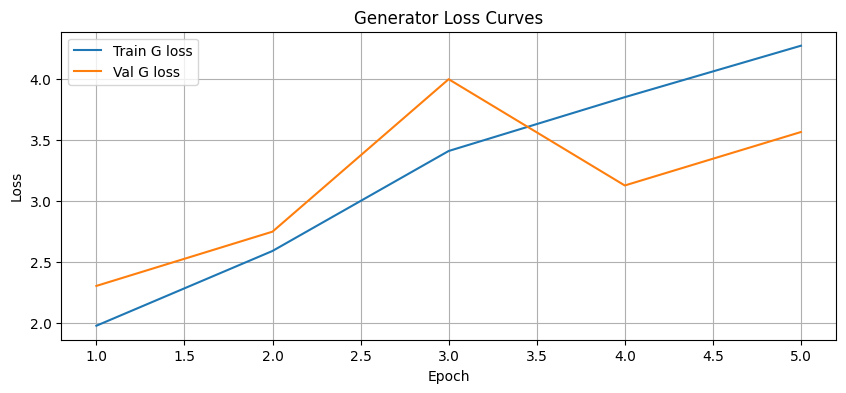

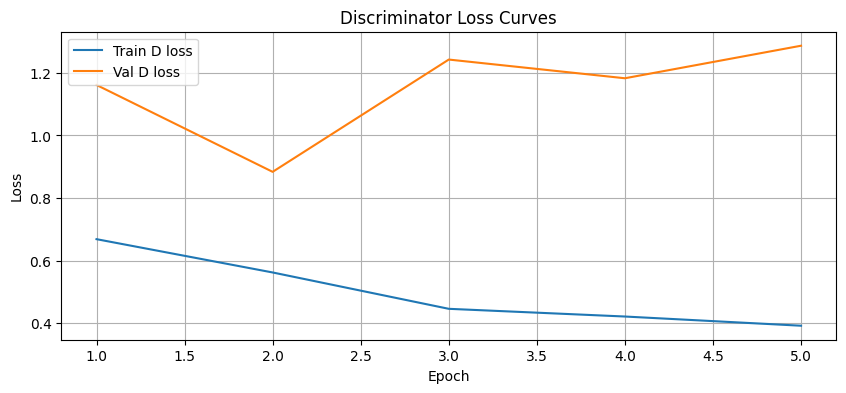

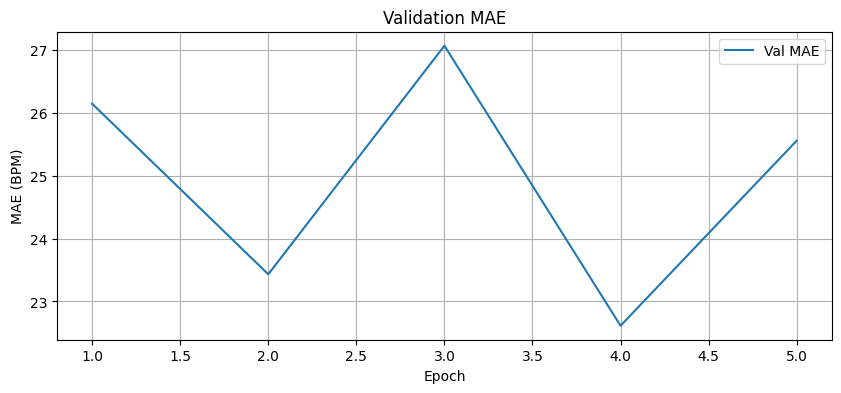

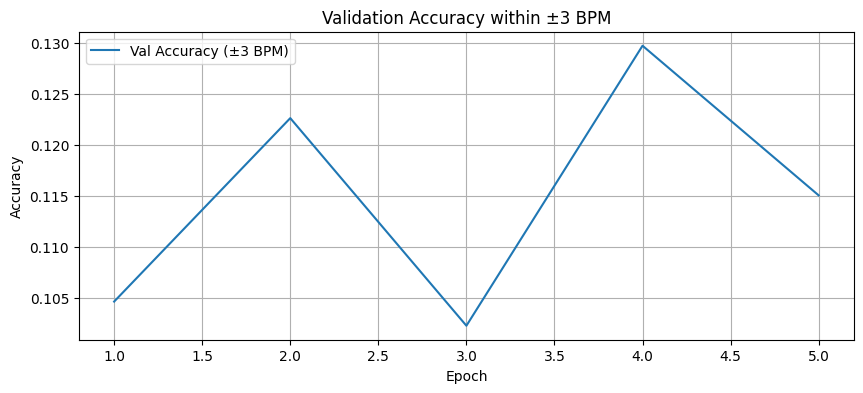

In [28]:
# ============================================================
# 17. Training curves
# ============================================================

epochs_range = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["train_g_total"], label="Train G loss")
plt.plot(epochs_range, history["val_g_total"], label="Val G loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator Loss Curves")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["train_d"], label="Train D loss")
plt.plot(epochs_range, history["val_d"], label="Val D loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Discriminator Loss Curves")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (BPM)")
plt.title("Validation MAE")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history["val_acc_pm3"], label="Val Accuracy (±3 BPM)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy within ±3 BPM")
plt.grid(True)
plt.legend()
plt.show()



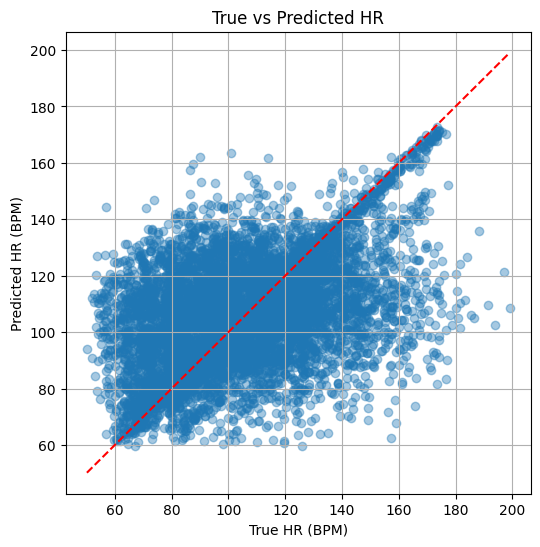

In [29]:
# ============================================================
# 19. Scatter plot of true vs predicted HR
# ============================================================

mask = ~np.isnan(y_test_pred_hr)
plt.figure(figsize=(6, 6))
plt.scatter(y_test_hr[mask], y_test_pred_hr[mask], alpha=0.4)
mn = min(np.min(y_test_hr[mask]), np.min(y_test_pred_hr[mask]))
mx = max(np.max(y_test_hr[mask]), np.max(y_test_pred_hr[mask]))
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("True HR (BPM)")
plt.ylabel("Predicted HR (BPM)")
plt.title("True vs Predicted HR")
plt.grid(True)
plt.show()


In [30]:
# ============================================================
# 20. Show random 20 samples and say right/wrong
# ============================================================
# "Right" = prediction within ±3 BPM
# ============================================================

valid_indices = np.where(~np.isnan(y_test_pred_hr))[0]
sample_indices = np.random.choice(valid_indices, size=min(20, len(valid_indices)), replace=False)

print("\n========== RANDOM 20 TEST SAMPLES ==========\n")

for count, idx in enumerate(sample_indices, start=1):
    true_hr = y_test_hr[idx]
    pred_hr = y_test_pred_hr[idx]
    err = abs(true_hr - pred_hr)
    status = "RIGHT" if err <= 3.0 else "WRONG"
    subj, segid = meta_test[idx]

    print(
        f"{count:02d}. Subject={subj}, Segment={segid}, "
        f"True HR={true_hr:.2f}, Pred HR={pred_hr:.2f}, "
        f"Abs Err={err:.2f} -> {status}"
    )



========== RANDOM 20 TEST SAMPLES ==========

01. Subject=S1, Segment=253, True HR=132.23, Pred HR=102.40, Abs Err=29.83 -> WRONG
02. Subject=S6, Segment=1111, True HR=130.84, Pred HR=128.92, Abs Err=1.92 -> RIGHT
03. Subject=S4, Segment=1576, True HR=96.92, Pred HR=95.29, Abs Err=1.64 -> RIGHT
04. Subject=S1, Segment=2080, True HR=60.69, Pred HR=124.54, Abs Err=63.85 -> WRONG
05. Subject=S4, Segment=1609, True HR=174.01, Pred HR=111.57, Abs Err=62.44 -> WRONG
06. Subject=S6, Segment=889, True HR=160.61, Pred HR=136.10, Abs Err=24.51 -> WRONG
07. Subject=S4, Segment=334, True HR=97.83, Pred HR=112.94, Abs Err=15.12 -> WRONG
08. Subject=S6, Segment=1216, True HR=106.73, Pred HR=119.20, Abs Err=12.47 -> WRONG
09. Subject=S6, Segment=733, True HR=127.13, Pred HR=122.18, Abs Err=4.95 -> WRONG
10. Subject=S6, Segment=380, True HR=147.37, Pred HR=149.13, Abs Err=1.76 -> RIGHT
11. Subject=S1, Segment=3007, True HR=176.99, Pred HR=90.14, Abs Err=86.85 -> WRONG
12. Subject=S4, Segment=2084, Tr

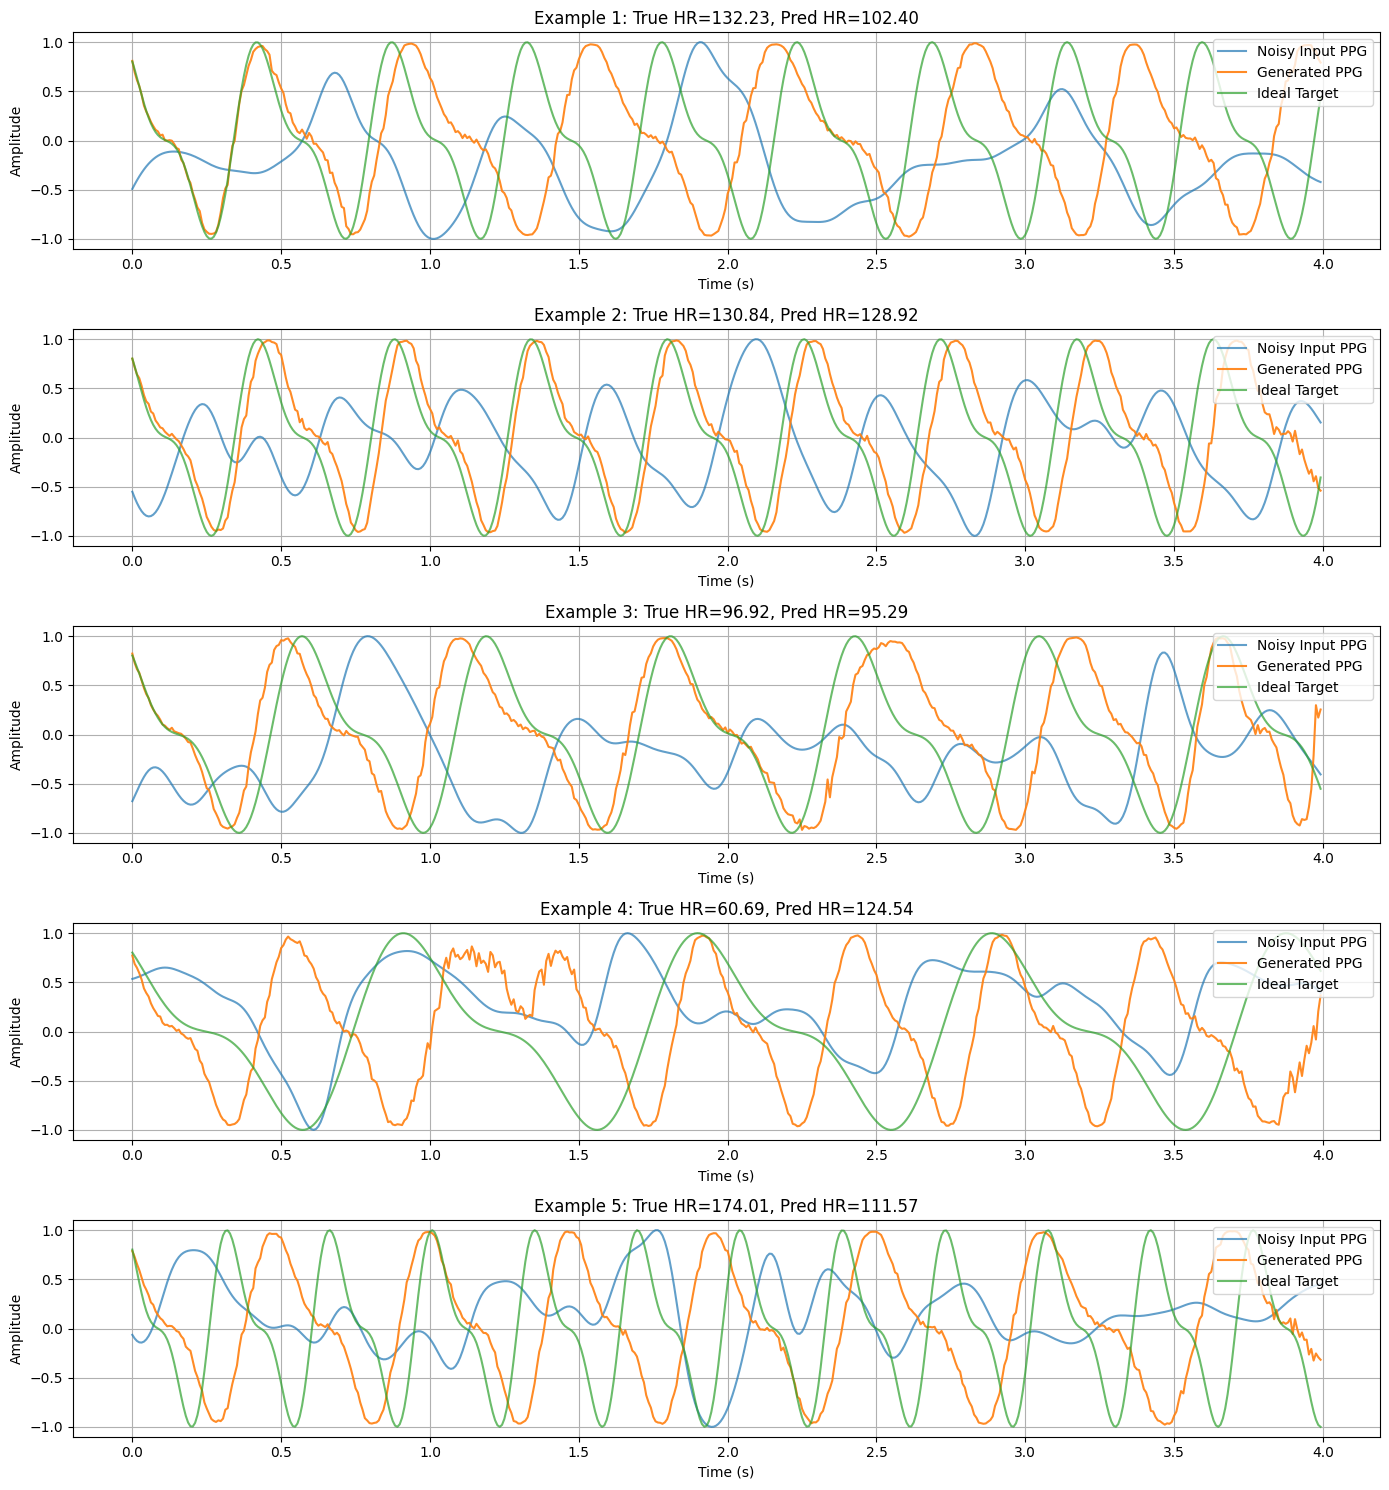

In [31]:
# ============================================================
# 21. Plot some qualitative examples
# ============================================================

num_examples = min(5, len(sample_indices))
plt.figure(figsize=(14, 3 * num_examples))

for row, idx in enumerate(sample_indices[:num_examples], start=1):
    noisy = X_test_noisy[idx, :, 0]
    fake = all_test_fake[idx, :, 0]
    ideal = X_test_ideal[idx, :, 0]

    t = np.arange(TRAIN_WINDOW_SAMPLES) / TARGET_FS

    plt.subplot(num_examples, 1, row)
    plt.plot(t, noisy, label="Noisy Input PPG", alpha=0.7)
    plt.plot(t, fake, label="Generated PPG", alpha=0.9)
    plt.plot(t, ideal, label="Ideal Target", alpha=0.7)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Example {row}: True HR={y_test_hr[idx]:.2f}, Pred HR={y_test_pred_hr[idx]:.2f}")
    plt.grid(True)
    plt.legend(loc="upper right")

plt.tight_layout()
plt.show()



In [32]:
# ============================================================
# 22. Final summary print
# ============================================================

print("\n========== FINAL SUMMARY ==========")
print(f"Best epoch based on validation MAE: {best_epoch}")
print(f"Best model path: {BEST_GEN_PATH}")
print(f"Last model path: {LAST_GEN_PATH}")
print(f"Test MAE: {test_metrics['mae']:.4f} BPM")
print(f"Test RMSE: {test_metrics['rmse']:.4f} BPM")
print(f"Test correlation: {test_metrics['corr']:.4f}")
print(f"Test accuracy within ±3 BPM: {test_metrics['acc_pm3']:.4f}")




========== FINAL SUMMARY ==========
Best epoch based on validation MAE: 4
Best model path: /kaggle/working/checkpoints/best_generator.weights.h5
Last model path: /kaggle/working/checkpoints/last_generator.weights.h5
Test MAE: 17.8960 BPM
Test RMSE: 24.1346 BPM
Test correlation: 0.4608
Test accuracy within ±3 BPM: 0.1740
